In [2]:
from sklearn import datasets, model_selection as skms
from sklearn import tree, ensemble
from sklearn import neighbors, metrics
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

def fit_predict_score(model, ds):
    return skms.cross_val_score(model, *ds, cv=10).mean()

stump  = tree.DecisionTreeClassifier(max_depth=1)
dtree  = tree.DecisionTreeClassifier(max_depth=3)
forest = ensemble.RandomForestClassifier(max_features=1, max_depth=1)

tree_classifiers = {'stump' : stump, 'dtree' : dtree, 'forest': forest}

max_est = 100

# Load the digits dataset
digits = datasets.load_digits()
digits_ftrs, digits_tgt = digits.data, digits.target

data = (digits_ftrs, digits_tgt)
stump_score   = fit_predict_score(stump, data)
tree_score    = fit_predict_score(dtree, data)
forest_scores = [fit_predict_score(forest.set_params(n_estimators=n),
                                   data)
                 for n in range(1,max_est+1)]

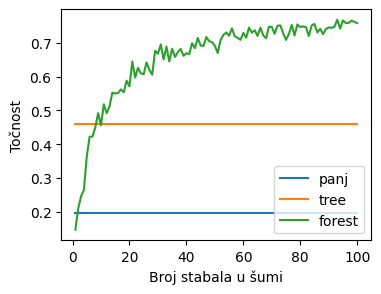

In [4]:
fig, ax = plt.subplots(figsize=(4,3))

xs = list(range(1,max_est+1))
ax.plot(xs, np.repeat(stump_score, max_est), label='panj')
ax.plot(xs, np.repeat(tree_score, max_est),  label='tree')
ax.plot(xs, forest_scores, label='forest')

ax.set_xlabel('Broj stabala u šumi')
ax.set_ylabel('Točnost')
ax.legend(loc='lower right');